In [ ]:
#Rodar esses partes basicas

In [ ]:
import shutil

shutil.move("/content/birimbau", "/content/drive/MyDrive")


'/content/drive/MyDrive/birimbau'

In [ ]:
cp -r /content/drive/MyDrive/replicacao_article/inbreast2 /content/inbreast_comparar

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -U ultralytics albumentations ipywidgets pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import os
import shutil
import random
from pathlib import Path
import yaml
from itertools import product
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import albumentations as A
from ultralytics import YOLO
from sklearn.model_selection import KFold
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
#vindrmammo dataset-----------

In [ ]:
#1-importar a api

# 1) Instalar a API do Kaggle
!pip install -q kaggle

# 2) Fazer upload do kaggle.json (arquivo da sua conta do Kaggle)
from google.colab import files
files.upload()

In [ ]:
#2-continua na importação

import os, shutil

# Criar pasta .kaggle e mover o kaggle.json pra lá
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Ajustar permissões
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle configurado ✅")

In [ ]:
#3-criar as pastas desejadas

import os

# Criar pastas destino

os.makedirs("/content/vindr_mammo_seg", exist_ok=True)


# 3) VinDr-Mammo MASS SEG – huuthocs/vindr-mammo-mammo-mass-segmentation-dataset
!kaggle datasets download -d huuthocs/vindr-mammo-mammo-mass-segmentation-dataset -p /content/vindr_mammo_seg --force
!unzip -q "/content/vindr_mammo_seg/vindr-mammo-mammo-mass-segmentation-dataset.zip" -d "/content/vindr_mammo_seg"


print("VinDr MASS    -> /content/vindr_mammo_seg")


Dataset URL: https://www.kaggle.com/datasets/huuthocs/vindr-mammo-mammo-mass-segmentation-dataset
License(s): CC-BY-SA-4.0
100% 3.06G/3.06G [00:44<00:00, 145MB/s]
100% 3.06G/3.06G [00:44<00:00, 74.3MB/s]
VinDr MASS    -> /content/vindr_mammo_seg


In [ ]:
#4-hajeitar o vindr,tratamento de masks e tudo mais

import os
import cv2
import numpy as np
import shutil
from glob import glob

# =========================
# CONFIGURAÇÕES
# =========================

# Diretório base do VinDr
BASE_DIR = "/content/vindr_mammo_seg"

IMAGES_DIR = os.path.join(BASE_DIR, "images")
MASKS_DIR  = os.path.join(BASE_DIR, "masks")

# Saída no formato YOLO
YOLO_ROOT   = "/content/vindr_v1_yolo"
YOLO_IMAGES = os.path.join(YOLO_ROOT, "images")
YOLO_LABELS = os.path.join(YOLO_ROOT, "labels")

# Classe que será usada (mass)
CLASS_ID = 0  # mude se quiser outro id

# Cria pastas de saída
os.makedirs(YOLO_IMAGES, exist_ok=True)
os.makedirs(YOLO_LABELS, exist_ok=True)

# =========================
# FUNÇÃO PARA PEGAR BBOX DA MASK
# =========================
def mask_to_bbox(mask: np.ndarray):
    """
    Recebe uma mask binária ou em escala de cinza e retorna:
    (x_center_norm, y_center_norm, w_norm, h_norm)
    no formato YOLO (normalizado).
    Retorna None se não encontrar nenhum pixel > 0.
    """
    H, W = mask.shape[:2]

    # Pixels onde a mask é > 0
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    x_min = int(xs.min())
    x_max = int(xs.max())
    y_min = int(ys.min())
    y_max = int(ys.max())

    # Calcula largura/altura da bbox
    bbox_w = x_max - x_min + 1
    bbox_h = y_max - y_min + 1

    x_center = x_min + bbox_w / 2.0
    y_center = y_min + bbox_h / 2.0

    # Normaliza para [0,1] (YOLO)
    x_center_norm = x_center / W
    y_center_norm = y_center / H
    w_norm = bbox_w / W
    h_norm = bbox_h / H

    return x_center_norm, y_center_norm, w_norm, h_norm

# =========================
# LOOP PRINCIPAL
# =========================

# Vamos agrupar labels por imagem:
# dict: { base_name: [linhas_yolo, ...] }
labels_dict = {}

mask_paths = sorted(glob(os.path.join(MASKS_DIR, "*.png")))
print(f"Encontradas {len(mask_paths)} masks em: {MASKS_DIR}")

sem_pixels = 0
sem_imagem = 0
com_bbox = 0

for mask_path in mask_paths:
    fname = os.path.basename(mask_path)

    # Ex.: "xxxx_mask.png" -> "xxxx"
    if fname.endswith("_mask.png"):
        base_name = fname.replace("_mask.png", "")
    else:
        # fallback genérico se o padrão for diferente
        base_name = os.path.splitext(fname)[0].replace("_mask", "")

    # Caminho da imagem correspondente
    # Aqui estou assumindo que a imagem tem o MESMO nome sem "_mask"
    image_path = os.path.join(IMAGES_DIR, base_name + ".png")

    if not os.path.exists(image_path):
        sem_imagem += 1
        print(f"[AVISO] Imagem não encontrada para mask: {fname}")
        continue

    # Ler mask em escala de cinza
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"[AVISO] Falha ao ler mask: {mask_path}")
        continue

    bbox = mask_to_bbox(mask)
    if bbox is None:
        sem_pixels += 1
        # sem pixels > 0, mask vazia
        continue

    x_center_norm, y_center_norm, w_norm, h_norm = bbox
    com_bbox += 1

    line = f"{CLASS_ID} {x_center_norm:.6f} {y_center_norm:.6f} {w_norm:.6f} {h_norm:.6f}"

    if base_name not in labels_dict:
        labels_dict[base_name] = []
    labels_dict[base_name].append(line)

print("\n===== RESUMO EXTRAÇÃO =====")
print(f"Masks processadas: {len(mask_paths)}")
print(f" - Masks com bbox válida: {com_bbox}")
print(f" - Masks vazias (sem pixels > 0): {sem_pixels}")
print(f" - Masks sem imagem correspondente: {sem_imagem}")
print(f"Imagens com pelo menos 1 bbox: {len(labels_dict)}")

# =========================
# SALVAR IMAGENS + LABELS
# =========================

salvas = 0

for base_name, yolo_lines in labels_dict.items():
    src_img = os.path.join(IMAGES_DIR, base_name + ".png")
    dst_img = os.path.join(YOLO_IMAGES, base_name + ".png")
    dst_lbl = os.path.join(YOLO_LABELS, base_name + ".txt")

    # Copiar imagem
    shutil.copy2(src_img, dst_img)

    # Escrever label
    with open(dst_lbl, "w") as f:
        for line in yolo_lines:
            f.write(line + "\n")

    salvas += 1

print("\n===== SAÍDA YOLO =====")
print(f"Imagens copiadas para : {YOLO_IMAGES}")
print(f"Labels gerados em     : {YOLO_LABELS}")
print(f"Total de imagens com label: {salvas}")


Encontradas 1107 masks em: /content/vindr_mammo_seg/masks

===== RESUMO EXTRAÇÃO =====
Masks processadas: 1107
 - Masks com bbox válida: 1107
 - Masks vazias (sem pixels > 0): 0
 - Masks sem imagem correspondente: 0
Imagens com pelo menos 1 bbox: 1107

===== SAÍDA YOLO =====
Imagens copiadas para : /content/vindr_v1_yolo/images
Labels gerados em     : /content/vindr_v1_yolo/labels
Total de imagens com label: 1107


Total de labels encontrados: 1107
Exemplo escolhido: f1cfe4acbb620d11c48b097b1a4c6941_cc10dced84a2f3279f63c683de9ae1b0
Imagem : /content/vindr_v1_yolo/images/f1cfe4acbb620d11c48b097b1a4c6941_cc10dced84a2f3279f63c683de9ae1b0.png
Mask   : /content/vindr_mammo_seg/masks/f1cfe4acbb620d11c48b097b1a4c6941_cc10dced84a2f3279f63c683de9ae1b0_mask.png
Label  : /content/vindr_v1_yolo/labels/f1cfe4acbb620d11c48b097b1a4c6941_cc10dced84a2f3279f63c683de9ae1b0.txt


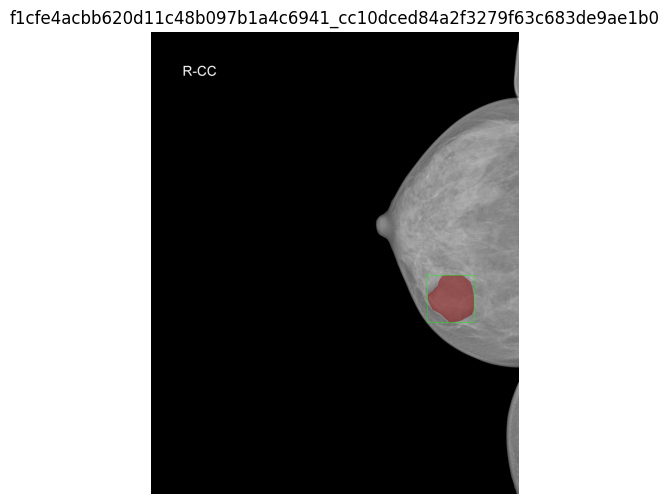

In [ ]:
#5-Exemplo de funcionamento com as labels

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# AJUSTAR AQUI SE PRECISAR
# =========================
BASE_DIR   = "/content/vindr_mammo_seg"
MASKS_DIR  = os.path.join(BASE_DIR, "masks")

YOLO_ROOT   = "/content/vindr_v1_yolo"
YOLO_IMAGES = os.path.join(YOLO_ROOT, "images")
YOLO_LABELS = os.path.join(YOLO_ROOT, "labels")
# =========================

# pegar todos os labels já gerados
label_files = [f for f in os.listdir(YOLO_LABELS) if f.endswith(".txt")]
print(f"Total de labels encontrados: {len(label_files)}")

if len(label_files) == 0:
    raise RuntimeError("Nenhum .txt encontrado em YOLO_LABELS. Gere as labels antes.")

# 👉 aleatório (se quiser fixo, comente essa linha e defina base_name manualmente)
chosen_label = random.choice(label_files)
base_name = os.path.splitext(chosen_label)[0]

# 👉 OU escolha um específico:
# base_name = "008b8e61390fcb4c0873258c15b0a53a_e13c80239d7714e3d964b5f3e37bcff6"
# chosen_label = base_name + ".txt"

print("Exemplo escolhido:", base_name)

img_path  = os.path.join(YOLO_IMAGES, base_name + ".png")
mask_path = os.path.join(MASKS_DIR, base_name + "_mask.png")
lbl_path  = os.path.join(YOLO_LABELS, chosen_label)

print("Imagem :", img_path)
print("Mask   :", mask_path)
print("Label  :", lbl_path)

# ler imagem
image = cv2.imread(img_path)
if image is None:
    raise RuntimeError(f"Não consegui ler a imagem: {img_path}")
H, W = image.shape[:2]

# ler mask
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
if mask is None:
    raise RuntimeError(f"Não consegui ler a mask: {mask_path}")

# normalizar mask pra 0–255 (só por segurança)
mask_bin = (mask > 0).astype(np.uint8) * 255

# criar overlay colorido só onde tem mask
mask_color = cv2.applyColorMap(mask_bin, cv2.COLORMAP_JET)

# copiar imagem pra fazer overlay
overlay = image.copy()

# aplicar máscara apenas onde mask > 0
alpha = 0.5  # transparência da máscara
mask_region = mask_bin > 0
overlay[mask_region] = cv2.addWeighted(
    image[mask_region], 1 - alpha,
    mask_color[mask_region], alpha,
    0
)

# ler label YOLO e desenhar bbox(s) na imagem com overlay
with open(lbl_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        xc, yc, w, h = map(float, parts[1:])

        # YOLO -> pixels
        bbox_w = w * W
        bbox_h = h * H
        x_center = xc * W
        y_center = yc * H

        x_min = int(x_center - bbox_w / 2)
        x_max = int(x_center + bbox_w / 2)
        y_min = int(y_center - bbox_h / 2)
        y_max = int(y_center + bbox_h / 2)

        # desenhar retângulo
        cv2.rectangle(overlay, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        # opcional: escrever id da classe
        cv2.putText(
            overlay, str(cls_id),
            (x_min, max(0, y_min - 5)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6,
            (0, 255, 0), 1, cv2.LINE_AA
        )

# mostrar apenas UMA imagem: original + mask + bbox
plt.figure(figsize=(6, 6))
plt.title(base_name)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()



In [ ]:
#Inbreast-> segue o mesmo fluxo da vindr importacao->tratamento

In [ ]:
#1-Importação da inbreast no kaggle

!pip install -q kagglehub

import kagglehub

# Baixar o dataset INbreast do Kaggle
path = kagglehub.dataset_download("ramanathansp20/inbreast-dataset")

print("Path to dataset files:", path)


100%|██████████| 1.93G/1.93G [01:31<00:00, 22.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ramanathansp20/inbreast-dataset/versions/1


In [ ]:
#2-Importando para o content

import shutil, os

src = path
dst = "/content/inbreast_kaggle"

os.makedirs(dst, exist_ok=True)
shutil.copytree(src, dst, dirs_exist_ok=True)

print("Copiado para:", dst)


Copiado para: /content/inbreast_kaggle


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.0 MB/s eta 0:00:00


In [ ]:
#3-tratamento da base
import os
import pydicom
import cv2
import numpy as np
import xml.etree.ElementTree as ET

# Đường dẫn đến các thư mục và file
INBREAST_DICOM_DIR = "/content/inbreast_kaggle/INbreast Release 1.0/AllDICOMs"
INBREAST_XML_DIR = "/content/inbreast_kaggle/INbreast Release 1.0/AllXML"
OUTPUT_DIR = "/content/inbreast"
IMAGES_INBREAST_DIR = os.path.join(OUTPUT_DIR, "images_inbreast")
MASKS_INBREAST_DIR = os.path.join(OUTPUT_DIR, "masks_inbreast")

# Tạo thư mục riêng cho INbreast nếu chưa tồn tại
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGES_INBREAST_DIR, exist_ok=True)
os.makedirs(MASKS_INBREAST_DIR, exist_ok=True)

# Hàm đọc hình ảnh từ file DICOM
def read_dicom_image(dicom_path):
    """Đọc file DICOM và trả về mảng numpy"""
    try:
        dicom = pydicom.dcmread(dicom_path)
        image = dicom.pixel_array
        # Chuyển sang định dạng 8-bit để lưu dưới dạng ảnh
        image = cv2.convertScaleAbs(image, alpha=(255.0/image.max()))
        # Chuyển sang định dạng 3 kênh để giữ màu
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        return image
    except Exception as e:
        print(f"Error reading DICOM {dicom_path}: {str(e)}")
        return None

# Hàm tạo mask từ file XML
def create_mask_from_xml(xml_path, image_shape):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        mask = np.zeros(image_shape[:2], dtype=np.uint8)  # Mask grayscale

        images = root.find(".//array/dict/array")  # Đường dẫn đến mảng ROIs
        if images is None:
            return None

        for roi in images.findall("dict"):
            num_points = None
            point_px_array = None
            children = list(roi)

            for i in range(0, len(children), 2):
                if children[i].tag == "key":
                    key_name = children[i].text
                    if key_name == "NumberOfPoints" and i + 1 < len(children):
                        num_points = int(children[i + 1].text)
                    elif key_name == "Point_px" and i + 1 < len(children):
                        point_px_array = children[i + 1]

            if num_points is None or num_points < 3:
                continue

            if point_px_array is None:
                continue

            points = []
            for point_str in point_px_array.findall("string"):
                point = point_str.text.strip("()").split(",")
                x = int(float(point[0]))
                y = int(float(point[1]))
                points.append([x, y])

            if points:
                points = np.array(points, dtype=np.int32)
                cv2.fillPoly(mask, [points], 255)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not [c for c in contours if cv2.contourArea(c) >= 1]:
            return None

        # Chuyển mask sang định dạng 3 kênh để phù hợp với ảnh gốc
        mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        return mask
    except Exception as e:
        print(f"Error creating mask from {xml_path}: {str(e)}")
        return None

# Hàm lưu hình ảnh và mask cho INbreast
def save_inbreast_image_and_mask(dicom_path, xml_path, images_dir, masks_dir, index):
    try:
        img = read_dicom_image(dicom_path)
        if img is None:
            return

        mask = create_mask_from_xml(xml_path, img.shape)
        if mask is None:
            return

        img_filename = f'image_{index:04d}.jpg'
        mask_filename = f'mask_{index:04d}.jpg'

        cv2.imwrite(os.path.join(images_dir, img_filename), img)
        cv2.imwrite(os.path.join(masks_dir, mask_filename), mask)

    except Exception as e:
        print(f"Error processing INbreast image {dicom_path}: {str(e)}")

# Hàm xử lý INbreast
def process_inbreast():
    xml_files = {os.path.splitext(f)[0]: os.path.join(INBREAST_XML_DIR, f) for f in os.listdir(INBREAST_XML_DIR) if f.endswith(".xml")}
    dicom_files = sorted([f for f in os.listdir(INBREAST_DICOM_DIR) if f.endswith(".dcm")])

    index = 1
    for dicom_file in dicom_files:
        dicom_base = dicom_file.split('_')[0]
        xml_path = xml_files.get(dicom_base)

        if xml_path and os.path.exists(xml_path):
            dicom_path = os.path.join(INBREAST_DICOM_DIR, dicom_file)
            save_inbreast_image_and_mask(dicom_path, xml_path, IMAGES_INBREAST_DIR, MASKS_INBREAST_DIR, index)
            index += 1

    print("Hoàn tất lưu hình ảnh và mask INbreast!")

# Chạy xử lý INbreast
if __name__ == "__main__":
    process_inbreast()

Hoàn tất lưu hình ảnh và mask INbreast!


In [ ]:
#Parte 4, criacao das labels apartir das masks

import os
import glob
import cv2
import numpy as np

# Caminhos
images_dir = "/content/inbreast/images_inbreast"
masks_dir  = "/content/inbreast/masks_inbreast"
labels_dir = "/content/inbreast/labels_inbreast"

os.makedirs(labels_dir, exist_ok=True)

# Extensões possíveis de máscara (ajuste se precisar)
mask_exts = ["*.jpg", "*.png", "*.jpeg", "*.tif", "*.tiff"]

mask_paths = []
for ext in mask_exts:
    mask_paths.extend(glob.glob(os.path.join(masks_dir, ext)))

mask_paths = sorted(mask_paths)

print(f"Encontradas {len(mask_paths)} máscaras.")

num_imgs_sem_mask = 0
total_boxes = 0

for mask_path in mask_paths:
    # Lê a máscara em escala de cinza
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"[AVISO] Não foi possível ler a máscara: {mask_path}")
        continue

    h, w = mask.shape[:2]

    # Binariza a máscara (caso não esteja binária)
    _, thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Encontra contornos externos (cada contorno = 1 lesão)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        print(f"[AVISO] Máscara sem pixels positivos (sem lesão): {mask_path}")
        num_imgs_sem_mask += 1
        continue

    # Descobre o nome base: mask_0001.jpg -> image_0001.txt
    mask_name = os.path.basename(mask_path)              # mask_0001.jpg
    stem, _ = os.path.splitext(mask_name)               # mask_0001

    # Troca "mask_" por "image_" pro nome da imagem/label
    image_stem = stem.replace("mask_", "image_")        # image_0001

    # Caminho da imagem correspondente (opcional, só pra checar se existe)
    image_path = os.path.join(images_dir, image_stem + ".jpg")
    if not os.path.exists(image_path):
        # Tenta outras extensões se quiser
        alternativas = [".png", ".jpeg", ".tif", ".tiff"]
        found = False
        for ext in alternativas:
            alt_path = os.path.join(images_dir, image_stem + ext)
            if os.path.exists(alt_path):
                image_path = alt_path
                found = True
                break
        if not found:
            print(f"[AVISO] Imagem correspondente não encontrada para {mask_name}. Pulando.")
            continue

    # Caminho do arquivo de label YOLO
    label_path = os.path.join(labels_dir, image_stem + ".txt")

    # Monta as linhas YOLO (uma por bounding box)
    yolo_lines = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh

        # Ignora áreas muito pequenas (ruído)
        if area < 5:
            continue

        # Centro do bounding box
        x_center = x + bw / 2.0
        y_center = y + bh / 2.0

        # Normaliza para [0,1]
        x_center_norm = x_center / w
        y_center_norm = y_center / h
        w_norm = bw / w
        h_norm = bh / h

        # Garante que está dentro de [0,1]
        x_center_norm = min(max(x_center_norm, 0.0), 1.0)
        y_center_norm = min(max(y_center_norm, 0.0), 1.0)
        w_norm = min(max(w_norm, 0.0), 1.0)
        h_norm = min(max(h_norm, 0.0), 1.0)

        # Classe 0 (pode trocar depois se tiver mais classes)
        class_id = 0

        yolo_line = f"{class_id} {x_center_norm:.6f} {y_center_norm:.6f} {w_norm:.6f} {h_norm:.6f}"
        yolo_lines.append(yolo_line)

    if len(yolo_lines) == 0:
        print(f"[AVISO] Nenhum bounding box válido em: {mask_path}")
        continue

    # Salva o arquivo .txt
    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    total_boxes += len(yolo_lines)

print("==== RESUMO ====")
print(f"Máscaras processadas: {len(mask_paths)}")
print(f"Imagens sem lesão (máscara vazia): {num_imgs_sem_mask}")
print(f"Total de bounding boxes gerados: {total_boxes}")
print(f"Labels salvos em: {labels_dir}")


Encontradas 300 máscaras.
==== RESUMO ====
Máscaras processadas: 300
Imagens sem lesão (máscara vazia): 0
Total de bounding boxes gerados: 2431
Labels salvos em: /content/inbreast/labels_inbreast


In [ ]:

#5-Tratamento de corte(crop) e aplicação de clahe
import os
import cv2
import numpy as np
from tqdm import tqdm

# ========= AJUSTE AQUI =========
IN_IMAGES_DIR  = "/content/inbreast/mass_only/images"
IN_LABELS_DIR  = "/content/inbreast/mass_only/labels"

OUT_IMAGES_DIR = "/content/inbreast/images_inbreast2"
OUT_LABELS_DIR = "/content/inbreast/labels_inbreast2"
# ===============================

os.makedirs(OUT_IMAGES_DIR, exist_ok=True)
os.makedirs(OUT_LABELS_DIR, exist_ok=True)

def read_yolo_labels(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, xc_n, yc_n, w_n, h_n = map(float, parts)
            xc = xc_n * img_w
            yc = yc_n * img_h
            bw = w_n * img_w
            bh = h_n * img_h
            x1 = xc - bw / 2
            y1 = yc - bh / 2
            x2 = xc + bw / 2
            y2 = yc + bh / 2
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes

def crop_breast_auto(img, margin=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(thresh) > 127:
        thresh = 255 - thresh
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    num_labels, labels = cv2.connectedComponents(thresh)
    if num_labels <= 1:
        h, w = img.shape[:2]
        return img.copy(), (0, 0, w, h)

    max_area = 0
    best_label = 1
    for lab in range(1, num_labels):
        area = np.sum(labels == lab)
        if area > max_area:
            max_area = area
            best_label = lab

    ys, xs = np.where(labels == best_label)
    if len(xs) == 0 or len(ys) == 0:
        h, w = img.shape[:2]
        return img.copy(), (0, 0, w, h)

    x1 = max(xs.min() - margin, 0)
    x2 = min(xs.max() + margin, img.shape[1] - 1)
    y1 = max(ys.min() - margin, 0)
    y2 = min(ys.max() + margin, img.shape[0] - 1)

    img_crop = img[y1:y2+1, x1:x2+1]
    return img_crop, (x1, y1, x2+1, y2+1)

def apply_clahe(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)
    return cv2.merge([gray_clahe]*3)

def adjust_boxes_to_crop(boxes, crop_box, new_w, new_h):
    cx1, cy1, cx2, cy2 = crop_box
    adjusted_pixel = []
    yolo_lines = []
    for cls, x1, y1, x2, y2 in boxes:
        nx1 = x1 - cx1
        ny1 = y1 - cy1
        nx2 = x2 - cx1
        ny2 = y2 - cy1

        if nx2 <= 0 or ny2 <= 0 or nx1 >= new_w or ny1 >= new_h:
            continue

        nx1 = max(0, min(nx1, new_w))
        ny1 = max(0, min(ny1, new_h))
        nx2 = max(0, min(nx2, new_w))
        ny2 = max(0, min(ny2, new_h))

        bw = nx2 - nx1
        bh = ny2 - ny1
        if bw <= 0 or bh <= 0:
            continue

        xc = nx1 + bw / 2
        yc = ny1 + bh / 2

        xc_n = xc / new_w
        yc_n = yc / new_h
        bw_n = bw / new_w
        bh_n = bh / new_h

        adjusted_pixel.append((cls, nx1, ny1, nx2, ny2))
        yolo_lines.append(f"{cls} {xc_n:.6f} {yc_n:.6f} {bw_n:.6f} {bh_n:.6f}")
    return adjusted_pixel, yolo_lines

img_exts = (".png", ".jpg", ".jpeg", ".bmp")

files = [f for f in os.listdir(IN_IMAGES_DIR)
         if f.lower().endswith(img_exts)]

print(f"Encontradas {len(files)} imagens para processar.")

for fname in tqdm(files):
    img_path = os.path.join(IN_IMAGES_DIR, fname)
    lbl_path = os.path.join(IN_LABELS_DIR,
                            os.path.splitext(fname)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    boxes_orig = read_yolo_labels(lbl_path, w, h)

    img_crop, crop_box = crop_breast_auto(img, margin=5)
    h_new, w_new = img_crop.shape[:2]

    boxes_crop_px, yolo_new_lines = adjust_boxes_to_crop(
        boxes_orig, crop_box, w_new, h_new
    )

    # aplica CLAHE
    img_proc = apply_clahe(img_crop)

    out_img_path = os.path.join(OUT_IMAGES_DIR, fname)
    out_lbl_path = os.path.join(
        OUT_LABELS_DIR, os.path.splitext(fname)[0] + ".txt"
    )

    cv2.imwrite(out_img_path, img_proc)
    with open(out_lbl_path, "w") as f:
        f.write("\n".join(yolo_new_lines))


Encontradas 84 imagens para processar.


100%|██████████| 84/84 [00:17<00:00,  4.76it/s]


In [ ]:
#6-remoção de imagens ruins em termos de bounding boxes desorganizadas

import os
import shutil

# Pastas originais
IMAGES_DIR = "/content/inbreast/images_inbreast2"
LABELS_DIR = "/content/inbreast/labels_inbreast2"

# Pastas de saída (base filtrada)
OUT_IMAGES_DIR = "/content/inbreast_filtered2/images"
OUT_LABELS_DIR = "/content/inbreast_filtered2/labels"

os.makedirs(OUT_IMAGES_DIR, exist_ok=True)
os.makedirs(OUT_LABELS_DIR, exist_ok=True)

# Extensões de imagem aceitas
IMG_EXTS = (".png", ".jpg", ".jpeg")

total_labels = 0
kept = 0
discarded = 0

for lbl_name in os.listdir(LABELS_DIR):
    if not lbl_name.endswith(".txt"):
        continue

    total_labels += 1
    lbl_path = os.path.join(LABELS_DIR, lbl_name)

    # Conta quantas linhas "de verdade" tem no arquivo (ignorando vazias)
    with open(lbl_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    num_boxes = len(lines)

    # Se tiver até 2 massas (<= 2 linhas), mantém
    if num_boxes <= 3:
        base = os.path.splitext(lbl_name)[0]

        # tenta achar a imagem correspondente
        img_path = None
        for ext in IMG_EXTS:
            candidate = os.path.join(IMAGES_DIR, base + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            print(f"⚠ Sem imagem para label: {lbl_path}")
            continue

        # copia imagem e label para a base filtrada
        shutil.copy2(img_path, os.path.join(OUT_IMAGES_DIR, os.path.basename(img_path)))
        shutil.copy2(lbl_path, os.path.join(OUT_LABELS_DIR, lbl_name))
        kept += 1
    else:
        discarded += 1

print(f"Total de labels analisadas: {total_labels}")
print(f"Mantidas (≤2 massas): {kept}")
print(f"Descartadas (>2 massas): {discarded}")
print(f"Base filtrada salva em: /content/inbreast_filtered")


Total de labels analisadas: 84
Mantidas (≤2 massas): 62
Descartadas (>2 massas): 22
Base filtrada salva em: /content/inbreast_filtered


In [ ]:
#cbis_ddsm database

In [ ]:
# 1-Instalar a API do Kaggle
!pip install -q kaggle

from google.colab import files
files.upload()  # ⬅️ selecione o arquivo kaggle.json que você baixou do site do Kaggle


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"isaiasfigueiredo","key":"280211b55b3284bd1b6414fa6b10fb68"}'}

In [ ]:
#2-importar

import os, shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle configurado ✅")


Kaggle configurado ✅


In [ ]:
#3- importar

import kagglehub

# Download latest version
path = kagglehub.dataset_download("makramettriki/cbis-ddsm-mass-new")

print("Path to dataset files:", path)

100%|██████████| 5.41G/5.41G [01:02<00:00, 92.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1


In [ ]:
#4-importar

import kagglehub
import os

# Baixar o dataset
path = kagglehub.dataset_download("makramettriki/cbis-ddsm-mass-new")

print("Path to dataset files:", path)
os.makedirs("/content/cbis_ddsm_mass_new", exist_ok=True)

# Ver o que tem dentro da pasta que o kagglehub baixou
!ls -R "{path}" | head -n 60


Path to dataset files: /root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1
/root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1:
CBIS-DDSM-Organized
test_verification.png
train_verification.png
val_verification.png

/root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1/CBIS-DDSM-Organized:
test
train
val

/root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1/CBIS-DDSM-Organized/test:
images
masks

/root/.cache/kagglehub/datasets/makramettriki/cbis-ddsm-mass-new/versions/1/CBIS-DDSM-Organized/test/images:
benign_Mass-Test_P_00126_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_00145_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00238_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_00340_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00369_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00433_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00457_LEFT_MLO_FULL_PRE.png
benign_Mass-Test_P_00707_RIGHT_CC_FULL_PRE.png
benign_Mass-Test_P_00766_

In [ ]:
#5- importar

dest = "/content/cbis_ddsm_mass_new"

# Copia TODO o conteúdo baixado para /content/cbis_ddsm_mass_new
!cp -r "{path}/." "{dest}/"

print("✔️ Copiado para:", dest)
!ls -R "{dest}" | head -n 60


✔️ Copiado para: /content/cbis_ddsm_mass_new
/content/cbis_ddsm_mass_new:
CBIS-DDSM-Organized
test_verification.png
train_verification.png
val_verification.png

/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized:
test
train
val

/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/test:
images
masks

/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/test/images:
benign_Mass-Test_P_00126_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_00145_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00238_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_00340_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00369_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00433_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_00457_LEFT_MLO_FULL_PRE.png
benign_Mass-Test_P_00707_RIGHT_CC_FULL_PRE.png
benign_Mass-Test_P_00766_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_01090_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_01108_RIGHT_MLO_FULL_PRE.png
benign_Mass-Test_P_01183_LEFT_CC_FULL_PRE.png
benign_Mass-Test_P_01378_RIGHT_CC_FULL_PRE.png
benign_Mass-Test_P_01416_RIGHT_CC_FU

In [ ]:
#6-rabalalhar pra criar as labels apartir das masks

import os
import glob
import cv2
import numpy as np
from tqdm import tqdm

BASE_DIR = "/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized"
SPLITS = ["train", "val", "test"]

# Extensões possíveis
IMG_EXTS  = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
MASK_EXTS = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

def find_mask_for_image(masks_dir, img_stem):
    """
    Procura um arquivo de máscara com o mesmo nome básico da imagem,
    testando várias extensões.
    """
    for ext in MASK_EXTS:
        candidate = os.path.join(masks_dir, img_stem + ext)
        if os.path.isfile(candidate):
            return candidate
    return None

def create_yolo_labels_for_split(split_name):
    split_dir   = os.path.join(BASE_DIR, split_name)
    images_dir  = os.path.join(split_dir, "images")
    masks_dir   = os.path.join(split_dir, "masks")
    labels_dir  = os.path.join(split_dir, "labels")

    os.makedirs(labels_dir, exist_ok=True)

    # Lista de imagens
    img_paths = []
    for ext in IMG_EXTS:
        img_paths.extend(glob.glob(os.path.join(images_dir, f"*{ext}")))

    print(f"\n=== Processando split: {split_name} ===")
    print(f"Encontradas {len(img_paths)} imagens.")

    sem_mask = 0
    mask_vazia = 0
    geradas = 0

    for img_path in tqdm(img_paths):
        img_name = os.path.basename(img_path)
        img_stem, _ = os.path.splitext(img_name)

        # Encontrar máscara correspondente
        mask_path = find_mask_for_image(masks_dir, img_stem)
        if mask_path is None:
            sem_mask += 1
            # print(f"[AVISO] Sem máscara para {img_name}")
            continue

        # Ler imagem para pegar tamanho
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"[ERRO] Não conseguiu ler imagem: {img_path}")
            continue

        h, w = img.shape[:2]

        # Ler máscara
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"[ERRO] Não conseguiu ler máscara: {mask_path}")
            continue

        # Pixels > 0 são a lesão
        ys, xs = np.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            mask_vazia += 1
            # print(f"[AVISO] Máscara vazia para {img_name}")
            continue

        x_min = xs.min()
        x_max = xs.max()
        y_min = ys.min()
        y_max = ys.max()

        # Coordenadas do centro e tamanho (em pixels)
        x_center = (x_min + x_max) / 2.0
        y_center = (y_min + y_max) / 2.0
        box_w    = (x_max - x_min)
        box_h    = (y_max - y_min)

        # Normalizar para YOLO (0-1)
        x_center_norm = x_center / w
        y_center_norm = y_center / h
        box_w_norm    = box_w    / w
        box_h_norm    = box_h    / h

        # Classe única: 0 (mass)
        label_line = f"0 {x_center_norm:.6f} {y_center_norm:.6f} {box_w_norm:.6f} {box_h_norm:.6f}\n"

        label_path = os.path.join(labels_dir, img_stem + ".txt")
        with open(label_path, "w") as f:
            f.write(label_line)

        geradas += 1

    print(f"Labels geradas: {geradas}")
    print(f"Imagens sem máscara: {sem_mask}")
    print(f"Máscaras vazias: {mask_vazia}")
    print(f"Labels salvas em: {labels_dir}")


# Rodar para train, val e test
for split in SPLITS:
    create_yolo_labels_for_split(split)

print("\n✅ Conversão concluída para todos os splits!")



=== Processando split: train ===
Encontradas 1274 imagens.


100%|██████████| 1274/1274 [07:40<00:00,  2.77it/s]


Labels geradas: 1274
Imagens sem máscara: 0
Máscaras vazias: 0
Labels salvas em: /content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/train/labels

=== Processando split: val ===
Encontradas 159 imagens.


100%|██████████| 159/159 [00:56<00:00,  2.83it/s]


Labels geradas: 159
Imagens sem máscara: 0
Máscaras vazias: 0
Labels salvas em: /content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/val/labels

=== Processando split: test ===
Encontradas 159 imagens.


100%|██████████| 159/159 [00:58<00:00,  2.72it/s]

Labels geradas: 159
Imagens sem máscara: 0
Máscaras vazias: 0
Labels salvas em: /content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/test/labels

✅ Conversão concluída para todos os splits!


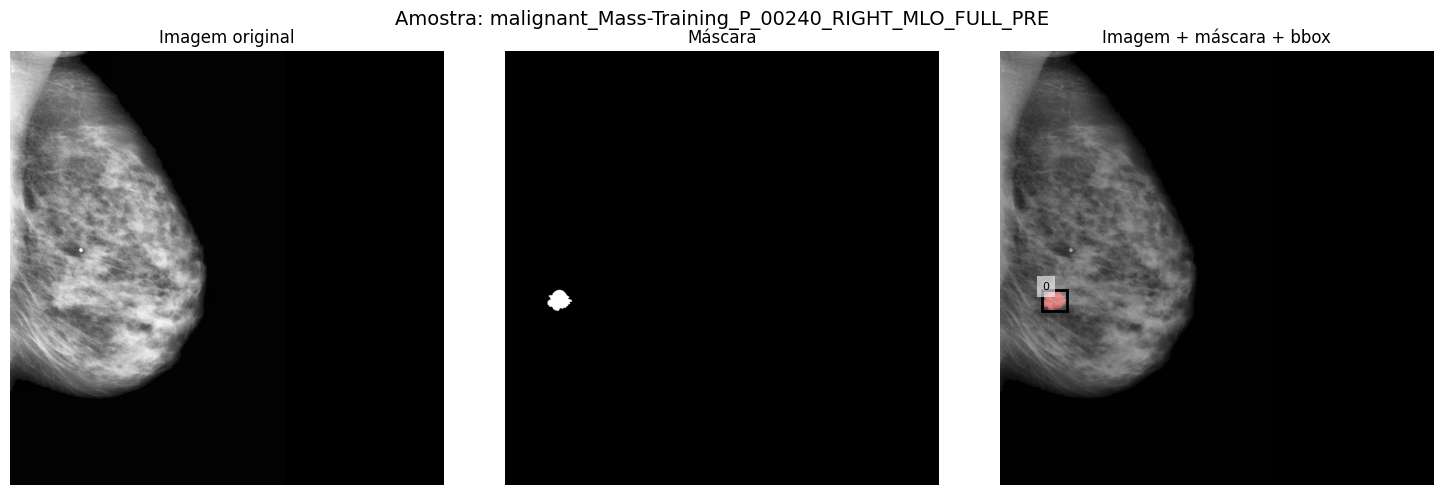

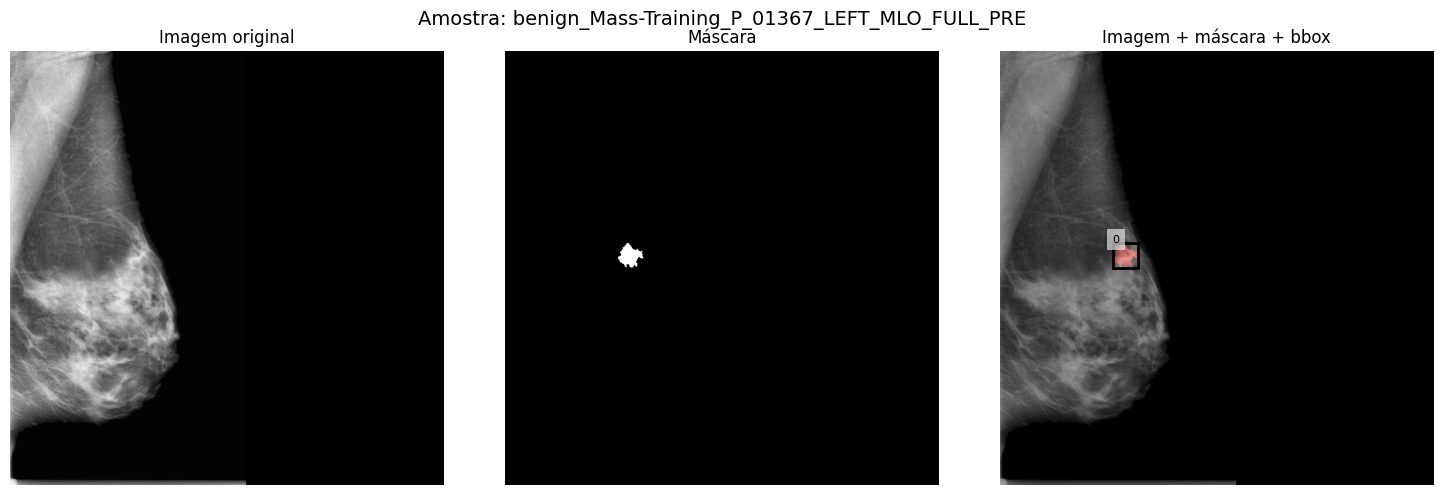

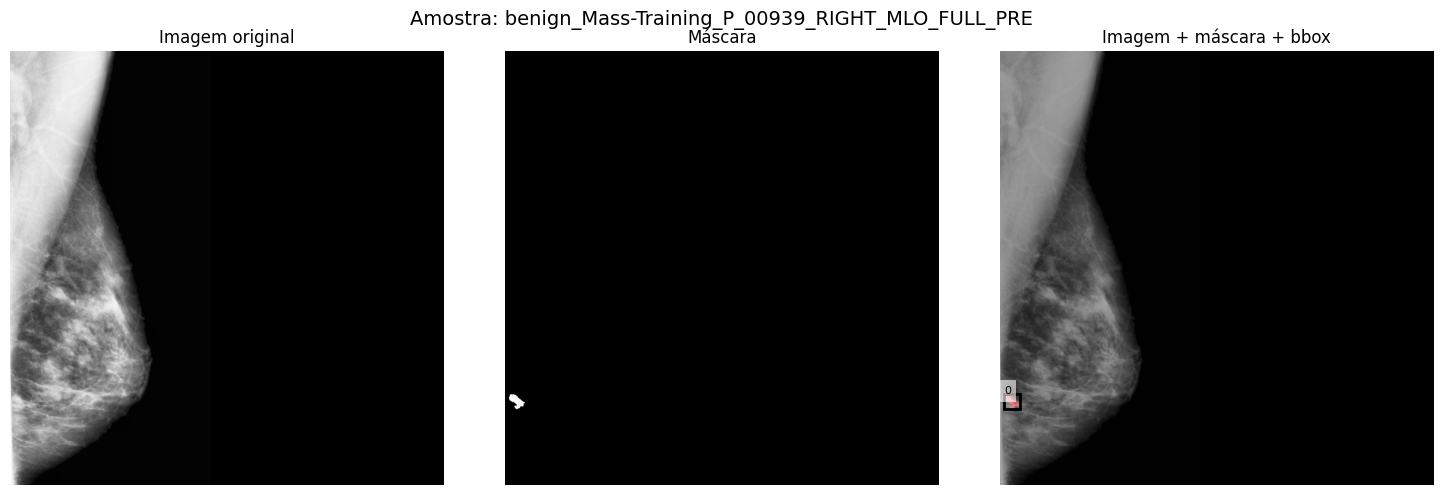

In [ ]:
#6- observar as masks

import os
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ================== CONFIGURAÇÃO DOS CAMINHOS ==================
BASE_DIR  = "/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/train"
IMG_DIR   = os.path.join(BASE_DIR, "images")
MASK_DIR  = os.path.join(BASE_DIR, "masks")
LABEL_DIR = os.path.join(BASE_DIR, "labels")

# extensões possíveis (ajusta se precisar)
IMG_EXTS = [".png", ".jpg", ".jpeg"]
MASK_EXT = ".png"   # geralmente as masks são .png
# ===============================================================


def carregar_imagem(caminho):
    """Lê imagem com OpenCV e converte BGR -> RGB."""
    img = cv2.imread(caminho, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Não foi possível ler a imagem: {caminho}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def carregar_mask(caminho):
    """Lê máscara em escala de cinza."""
    m = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Não foi possível ler a máscara: {caminho}")
    return m


def ler_labels_yolo(label_path, img_w, img_h):
    """
    Lê arquivo .txt no formato YOLO:
    class x_center y_center width height (normalizados)
    Retorna lista de dicionários: {cls, x1, y1, x2, y2}
    """
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            x_c, y_c, w, h = map(float, parts[1:5])

            # converte pra coordenadas em pixels
            x_c *= img_w
            y_c *= img_h
            w   *= img_w
            h   *= img_h

            x1 = x_c - w / 2
            y1 = y_c - h / 2
            x2 = x_c + w / 2
            y2 = y_c + h / 2

            boxes.append({
                "cls": cls,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2
            })
    return boxes


def mostrar_amostra_aleatoria(n_amostras=1):
    """
    Sorteia n_amostras labels aleatórias e mostra:
      - Imagem original
      - Máscara
      - Imagem + máscara + bounding boxes
    """
    label_files = sorted(glob.glob(os.path.join(LABEL_DIR, "*.txt")))
    if not label_files:
        print("Nenhum arquivo .txt encontrado em:", LABEL_DIR)
        return

    for _ in range(n_amostras):
        label_path = random.choice(label_files)
        base_name = os.path.splitext(os.path.basename(label_path))[0]

        # monta caminhos da imagem e da máscara
        img_path = None
        for ext in IMG_EXTS:
            tentativa = os.path.join(IMG_DIR, base_name + ext)
            if os.path.exists(tentativa):
                img_path = tentativa
                break

        mask_path = os.path.join(MASK_DIR, base_name + MASK_EXT)

        if img_path is None:
            print(f"[AVISO] Imagem não encontrada para {base_name}, pulando...")
            continue
        if not os.path.exists(mask_path):
            print(f"[AVISO] Máscara não encontrada para {base_name}, pulando...")
            continue

        # carrega imagem e máscara
        img = carregar_imagem(img_path)
        mask = carregar_mask(mask_path)

        h, w = img.shape[:2]

        # garante que a máscara tenha o mesmo tamanho da imagem
        if mask.shape != (h, w):
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # binariza a máscara para overlay
        mask_bin = mask > 0

        # lê labels YOLO
        boxes = ler_labels_yolo(label_path, w, h)

        # ================== PLOTAGEM ==================
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"Amostra: {base_name}", fontsize=14)

        # 1) Imagem original
        axes[0].imshow(img)
        axes[0].set_title("Imagem original")
        axes[0].axis("off")

        # 2) Máscara sozinha
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("Máscara")
        axes[1].axis("off")

        # 3) Imagem + máscara + bounding boxes
        axes[2].imshow(img)
        # overlay em vermelho
        overlay = np.zeros_like(img)
        overlay[mask_bin] = [255, 0, 0]  # vermelho
        axes[2].imshow(overlay, alpha=0.35)

        # desenhar as bounding boxes por cima da máscara
        for b in boxes:
            x1, y1, x2, y2 = b["x1"], b["y1"], b["x2"], b["y2"]
            rect = Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
            axes[2].add_patch(rect)
            axes[2].text(
                x1,
                y1 - 2,
                str(b["cls"]),
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
            )

        axes[2].set_title("Imagem + máscara + bbox")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()
        # ============================================


# ====== CHAMAR PARA TESTAR UMA OU MAIS ALEATÓRIAS ======
mostrar_amostra_aleatoria(n_amostras=3)  # mude o 3 pro número que quiser


In [ ]:
#7-tratamento da base crop e aplicacao de sharpen.

import os
import cv2
import numpy as np
from tqdm import tqdm

# ========= AJUSTE AQUI =========
IN_IMAGES_DIR  = "/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/test/images"
IN_LABELS_DIR  = "/content/cbis_ddsm_mass_new/CBIS-DDSM-Organized/test/labels"

OUT_IMAGES_DIR = "/content/biz/test/images"
OUT_LABELS_DIR = "/content/biz/test/labels"
# ===============================

os.makedirs(OUT_IMAGES_DIR, exist_ok=True)
os.makedirs(OUT_LABELS_DIR, exist_ok=True)

def read_yolo_labels(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, xc_n, yc_n, w_n, h_n = map(float, parts)
            xc = xc_n * img_w
            yc = yc_n * img_h
            bw = w_n * img_w
            bh = h_n * img_h
            x1 = xc - bw / 2
            y1 = yc - bh / 2
            x2 = xc + bw / 2
            y2 = yc + bh / 2
            boxes.append((int(cls), x1, y1, x2, y2))
    return boxes

def crop_breast_auto(img, margin=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if np.mean(thresh) > 127:
        thresh = 255 - thresh
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    num_labels, labels = cv2.connectedComponents(thresh)
    if num_labels <= 1:
        h, w = img.shape[:2]
        return img.copy(), (0, 0, w, h)

    max_area = 0
    best_label = 1
    for lab in range(1, num_labels):
        area = np.sum(labels == lab)
        if area > max_area:
            max_area = area
            best_label = lab

    ys, xs = np.where(labels == best_label)
    if len(xs) == 0 or len(ys) == 0:
        h, w = img.shape[:2]
        return img.copy(), (0, 0, w, h)

    x1 = max(xs.min() - margin, 0)
    x2 = min(xs.max() + margin, img.shape[1] - 1)
    y1 = max(ys.min() - margin, 0)
    y2 = min(ys.max() + margin, img.shape[0] - 1)

    img_crop = img[y1:y2+1, x1:x2+1]
    return img_crop, (x1, y1, x2+1, y2+1)

def apply_clahe(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray)
    return cv2.merge([gray_clahe]*3)

def adjust_boxes_to_crop(boxes, crop_box, new_w, new_h):
    cx1, cy1, cx2, cy2 = crop_box
    adjusted_pixel = []
    yolo_lines = []
    for cls, x1, y1, x2, y2 in boxes:
        nx1 = x1 - cx1
        ny1 = y1 - cy1
        nx2 = x2 - cx1
        ny2 = y2 - cy1

        if nx2 <= 0 or ny2 <= 0 or nx1 >= new_w or ny1 >= new_h:
            continue

        nx1 = max(0, min(nx1, new_w))
        ny1 = max(0, min(ny1, new_h))
        nx2 = max(0, min(nx2, new_w))
        ny2 = max(0, min(ny2, new_h))

        bw = nx2 - nx1
        bh = ny2 - ny1
        if bw <= 0 or bh <= 0:
            continue

        xc = nx1 + bw / 2
        yc = ny1 + bh / 2

        xc_n = xc / new_w
        yc_n = yc / new_h
        bw_n = bw / new_w
        bh_n = bh / new_h

        adjusted_pixel.append((cls, nx1, ny1, nx2, ny2))
        yolo_lines.append(f"{cls} {xc_n:.6f} {yc_n:.6f} {bw_n:.6f} {bh_n:.6f}")
    return adjusted_pixel, yolo_lines

img_exts = (".png", ".jpg", ".jpeg", ".bmp")

files = [f for f in os.listdir(IN_IMAGES_DIR)
         if f.lower().endswith(img_exts)]

print(f"Encontradas {len(files)} imagens para processar.")

for fname in tqdm(files):
    img_path = os.path.join(IN_IMAGES_DIR, fname)
    lbl_path = os.path.join(IN_LABELS_DIR,
                            os.path.splitext(fname)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    boxes_orig = read_yolo_labels(lbl_path, w, h)

    img_crop, crop_box = crop_breast_auto(img, margin=5)
    h_new, w_new = img_crop.shape[:2]

    boxes_crop_px, yolo_new_lines = adjust_boxes_to_crop(
        boxes_orig, crop_box, w_new, h_new
    )

    # aplica CLAHE
    img_proc = apply_clahe(img_crop)

    out_img_path = os.path.join(OUT_IMAGES_DIR, fname)
    out_lbl_path = os.path.join(
        OUT_LABELS_DIR, os.path.splitext(fname)[0] + ".txt"
    )

    cv2.imwrite(out_img_path, img_proc)
    with open(out_lbl_path, "w") as f:
        f.write("\n".join(yolo_new_lines))


Encontradas 159 imagens para processar.


100%|██████████| 159/159 [15:15<00:00,  5.76s/it]


In [ ]:
#--------------------------------